In [ ]:
import numpy as np
from sklearn.neighbors import NearestCentroid
from sklearn.svm import SVC
from sklearn.model_selection import KFold, LeaveOneOut

# =====================================================================
# GLOBAL SIMULATION CONFIGURATION
# =====================================================================
n_simulations = 100        # Number of simulated datasets to run. Paper uses 1000.
n_samples = 40             # 40 samples per dataset (20 of each class)
n_features = 6000          # 6,000 synthetic genes [4]
n_test_samples = 1000      # Size of independent test set (paper uses 20,000)

# Initialize a primary generator to build our shared test set
test_rng = np.random.default_rng(seed=1)

# Generate the shared static test set (represents the true population)
print(f"Generating {n_test_samples} independent test samples...")
X_test = test_rng.normal(loc=0.0, scale=1.0, size=(n_test_samples, n_features))
y_test = np.concatenate([
    np.repeat(-1, n_test_samples // 2), 
    np.repeat(1, n_test_samples // 2)
])

print("Initialization complete! Global arrays and test sets are ready in memory.")

Generating 1000 independent test samples...
Initialization complete! Global arrays and test sets are ready in memory.


In [ ]:
# =====================================================================
# SHRUNKEN CENTROIDS SIMULATION
# =====================================================================
# Re-initialize local generator to ensure reproducibility of dataset sequences
rng_sc = np.random.default_rng(seed=1)

# Define Delta candidates for parameter sweep
deltas = np.linspace(0.01, 1.0, 20)  # Use 20 for fast testing

sc_cv_errors = []
sc_true_errors = []

print("Starting Shrunken Centroids simulation runs...")
for sim in range(n_simulations):
    # --- Generate the 40-sample null training dataset ---
    X_null = rng_sc.normal(loc=0.0, scale=1.0, size=(n_samples, n_features))
    y_null = np.concatenate([np.repeat(-1, 20), np.repeat(1, 20)])
    
    # Jointly shuffle to randomize fold compositions
    shuffle_idx = rng_sc.permutation(n_samples)
    X_null = X_null[shuffle_idx]
    y_null = y_null[shuffle_idx]
    
    # --- 10-Fold CV Parameter Tuning Loop ---
    kf = KFold(n_splits=10, shuffle=True)
    cv_errors_for_deltas = []
    
    for delta in deltas:
        fold_errors = []
        for train_idx, val_idx in kf.split(X_null):
            X_train, X_val = X_null[train_idx], X_null[val_idx]
            y_train, y_val = y_null[train_idx], y_null[val_idx]
            
            clf = NearestCentroid(shrink_threshold=delta)
            clf.fit(X_train, y_train)
            fold_errors.append(np.mean(clf.predict(X_val) != y_val))
            
        cv_errors_for_deltas.append(np.mean(fold_errors))
        
    # --- Apply Tie-Breaker (Choose largest delta with minimum error) ---
    min_cv_error = min(cv_errors_for_deltas)
    best_deltas = [d for d, err in zip(deltas, cv_errors_for_deltas) if err == min_cv_error]
    optimal_delta = max(best_deltas)
    
    sc_cv_errors.append(min_cv_error)
    
    # --- Evaluate True Error on Shared Test Set ---
    final_clf = NearestCentroid(shrink_threshold=optimal_delta)
    final_clf.fit(X_null, y_null)
    
    sc_true_errors.append(np.mean(final_clf.predict(X_test) != y_test))
    
    if (sim + 1) % max(1, n_simulations // 10) == 0:
        print(f"  Completed {sim + 1}/{n_simulations} runs... (Last CV Error: {min_cv_error*100:.1f}%)")

print("\n--- SHRUNKEN CENTROIDS RESULTS ---")
print(f"Mean Standard 10-Fold CV Error: {np.mean(sc_cv_errors)*100:.1f}%")
print(f"Mean True Test Error:          {np.mean(sc_true_errors)*100:.1f}%")

Starting Shrunken Centroids simulation runs...
  Completed 10/100 runs... (Last CV Error: 42.5%)
  Completed 20/100 runs... (Last CV Error: 30.0%)
  Completed 30/100 runs... (Last CV Error: 57.5%)
  Completed 40/100 runs... (Last CV Error: 37.5%)
  Completed 50/100 runs... (Last CV Error: 32.5%)
  Completed 60/100 runs... (Last CV Error: 40.0%)
  Completed 70/100 runs... (Last CV Error: 35.0%)
  Completed 80/100 runs... (Last CV Error: 30.0%)
  Completed 90/100 runs... (Last CV Error: 35.0%)
  Completed 100/100 runs... (Last CV Error: 32.5%)

--- SHRUNKEN CENTROIDS RESULTS ---
Mean Standard 10-Fold CV Error: 40.7%
Mean True Test Error:          50.1%


In [3]:
import numpy as np
from sklearn.neighbors import NearestCentroid
from sklearn.svm import SVC
from sklearn.model_selection import KFold, LeaveOneOut

# =====================================================================
# SUPPORT VECTOR MACHINE (SVM) SIMULATION
# =====================================================================
# Re-initialize local generator with the same seed to match dataset sequences exactly!
rng_svm = np.random.default_rng(seed=1)

# Define 5x5 parameter grid search space
C_grid = np.logspace(-5, 15, 5, base=2)
gamma_grid = np.logspace(-15, 3, 5, base=2)

svm_cv_errors = []
svm_true_errors = []

print("Starting SVM simulation runs...")
for sim in range(n_simulations):
    # --- Generate the 40-sample null training dataset ---
    X_null = rng_svm.normal(loc=0.0, scale=1.0, size=(n_samples, n_features))
    y_null = np.concatenate([np.repeat(-1, 20), np.repeat(1, 20)])
    
    # Jointly shuffle to randomize fold compositions
    shuffle_idx = rng_svm.permutation(n_samples)
    X_null = X_null[shuffle_idx]
    y_null = y_null[shuffle_idx]
    
    # --- Leave-One-Out CV Parameter Tuning Loop ---
    loo = LeaveOneOut()
    loo_errors = np.zeros((n_samples, len(C_grid), len(gamma_grid)))
    
    for fold_idx, (train_idx, val_idx) in enumerate(loo.split(X_null)):
        X_train, X_val = X_null[train_idx], X_null[val_idx]
        y_train, y_val = y_null[train_idx], y_null[val_idx]
        
        # 1. Feature Selection inside fold: Vectorized Two-Sample t-Test [8, 9]
        X_c1 = X_train[y_train == 1]
        X_c2 = X_train[y_train == -1]
        
        m1, m2 = np.mean(X_c1, axis=0), np.mean(X_c2, axis=0)
        v1, v2 = np.var(X_c1, axis=0, ddof=1), np.var(X_c2, axis=0, ddof=1)
        n1, n2 = X_c1.shape[0], X_c2.shape[0]  # Extract sample counts as scalars
        
        t_stats = (m1 - m2) / np.sqrt(v1/n1 + v2/n2 + 1e-9)
        top_3_idx = np.argsort(np.abs(t_stats))[-3:]  # Best 3 features [7]
        
        X_train_sub = X_train[:, top_3_idx]
        X_val_sub = X_val[:, top_3_idx]
        
        # 2. Grid Search over C and gamma
        for c_idx, C_val in enumerate(C_grid):
            for g_idx, gamma_val in enumerate(gamma_grid):
                clf = SVC(C=C_val, kernel='rbf', gamma=gamma_val)
                clf.fit(X_train_sub, y_train)
                
                pred = clf.predict(X_val_sub)
                loo_errors[fold_idx, c_idx, g_idx] = int(pred[0] != y_val[0])
                
    # Calculate average CV error across all 40 folds
    cv_error_matrix = np.mean(loo_errors, axis=0)
    
    # --- Parameter Optimization & Tie-Breaking ---
    min_cv_error = np.min(cv_error_matrix)
    svm_cv_errors.append(min_cv_error)
    
    best_param_indices = np.argwhere(cv_error_matrix == min_cv_error)
    best_pair = best_param_indices[0]  # Extract first index pair
    c_idx, g_idx = best_pair[0], best_pair[1]
    optimal_C = C_grid[c_idx]
    optimal_gamma = gamma_grid[g_idx]
    
    # --- Evaluate True Error using top 3 features of all 40 samples [3] ---
    X_c1_all = X_null[y_null == 1]
    X_c2_all = X_null[y_null == -1]
    
    m1_all, m2_all = np.mean(X_c1_all, axis=0), np.mean(X_c2_all, axis=0)
    v1_all, v2_all = np.var(X_c1_all, axis=0, ddof=1), np.var(X_c2_all, axis=0, ddof=1)
    n1_all, n2_all = X_c1_all.shape[0], X_c2_all.shape[0]  # Extract sample counts as scalars
    
    t_stats_all = (m1_all - m2_all) / np.sqrt(v1_all/n1_all + v2_all/n2_all + 1e-9)
    top_3_idx_all = np.argsort(np.abs(t_stats_all))[-3:]
    
    X_null_sub = X_null[:, top_3_idx_all]
    X_test_sub = X_test[:, top_3_idx_all]
    
    final_clf = SVC(C=optimal_C, kernel='rbf', gamma=optimal_gamma)
    final_clf.fit(X_null_sub, y_null)
    
    svm_true_errors.append(np.mean(final_clf.predict(X_test_sub) != y_test))
    
    if (sim + 1) % max(1, n_simulations // 10) == 0:
        print(f"  Completed {sim + 1}/{n_simulations} runs... (Last CV Error: {min_cv_error*100:.1f}%)")

print("\n--- SVM RESULTS ---")
print(f"Mean LOOCV Error: {np.mean(svm_cv_errors)*100:.1f}%")
print(f"Mean True Test Error: {np.mean(svm_true_errors)*100:.1f}%")

Starting SVM simulation runs...
  Completed 10/100 runs... (Last CV Error: 40.0%)
  Completed 20/100 runs... (Last CV Error: 35.0%)
  Completed 30/100 runs... (Last CV Error: 35.0%)
  Completed 40/100 runs... (Last CV Error: 35.0%)
  Completed 50/100 runs... (Last CV Error: 20.0%)
  Completed 60/100 runs... (Last CV Error: 42.5%)
  Completed 70/100 runs... (Last CV Error: 65.0%)
  Completed 80/100 runs... (Last CV Error: 37.5%)
  Completed 90/100 runs... (Last CV Error: 32.5%)
  Completed 100/100 runs... (Last CV Error: 57.5%)

--- SVM RESULTS ---
Mean LOOCV Error: 40.6%
Mean True Test Error: 49.9%


In [ ]:
# =====================================================================
# CODE BLOCK 4A: NESTED CV FOR SHRUNKEN CENTROIDS (NULL DATA)
# =====================================================================
import numpy as np
from sklearn.neighbors import NearestCentroid
from sklearn.model_selection import KFold, LeaveOneOut

# Your optimized fast testing parameters
n_simulations_sc = 20      # Reduced to 20 simulations
n_test_samples_sc = 1000      # Size of independent test set (paper uses 20,000)
n_samples = 40               # 40 samples per simulation (20 of each class)
n_features = 6000            # 6,000 synthetic genes

# Number of deltas restricted to 10 for rapid evaluation
deltas = np.linspace(0.01, 1.0, 10) 

# Re-initialize local generator to ensure perfect matching sequence
rng_sc_nest = np.random.default_rng(seed=1)

# Generate null test set
X_test_sc = rng_sc_nest.normal(loc=0.0, scale=1.0, size=(n_test_samples_sc, n_features))
y_test_sc = np.concatenate([np.repeat(-1, n_test_samples_sc // 2), np.repeat(1, n_test_samples_sc // 2)])

sc_true_errors_nested = []
sc_nested_errors = []

print("Starting Shrunken Centroids Nested CV simulation runs...")
for sim in range(n_simulations_sc):
    # Generate 40-sample null training set
    X_null = rng_sc_nest.normal(loc=0.0, scale=1.0, size=(n_samples, n_features))
    y_null = np.concatenate([np.repeat(-1, 20), np.repeat(1, 20)])
    
    shuffle_idx = rng_sc_nest.permutation(n_samples)
    X_null = X_null[shuffle_idx]
    y_null = y_null[shuffle_idx]
    
    # 1. Standard 10-Fold CV on ALL 40 samples to get the "Optimized" classifier's True Error [1]
    kf_std = KFold(n_splits=10, shuffle=True)
    std_cv_errors = []
    for delta in deltas:
        fold_errors = []
        for train_idx, val_idx in kf_std.split(X_null):
            clf = NearestCentroid(shrink_threshold=delta)
            clf.fit(X_null[train_idx], y_null[train_idx])
            fold_errors.append(np.mean(clf.predict(X_null[val_idx]) != y_null[val_idx]))
        std_cv_errors.append(np.mean(fold_errors))
        
    optimal_delta = max([d for d, err in zip(deltas, std_cv_errors) if err == min(std_cv_errors)])
    
    # Train optimized classifier on all 40 samples and predict on independent test set
    sc_final_clf = NearestCentroid(shrink_threshold=optimal_delta)
    sc_final_clf.fit(X_null, y_null)
    sc_true_errors_nested.append(np.mean(sc_final_clf.predict(X_test_sc) != y_test_sc))
    
    # 2. Nested LOOCV Loop [1]
    loo_outer = LeaveOneOut()
    sc_outer_predictions = []
    
    for outer_train_idx, outer_test_idx in loo_outer.split(X_null):
        X_outer_train, X_outer_test = X_null[outer_train_idx], X_null[outer_test_idx]
        y_outer_train, y_outer_test = y_null[outer_train_idx], y_null[outer_test_idx]
        
        # Inner Loop: Run 10-Fold CV on the 39 training samples to select delta [1]
        kf_inner = KFold(n_splits=10, shuffle=True)
        inner_cv_errors = []
        
        for delta in deltas:
            inner_fold_errors = []
            for inner_train_idx, inner_val_idx in kf_inner.split(X_outer_train):
                clf = NearestCentroid(shrink_threshold=delta)
                clf.fit(X_outer_train[inner_train_idx], y_outer_train[inner_train_idx])
                inner_fold_errors.append(np.mean(clf.predict(X_outer_train[inner_val_idx]) != y_outer_train[inner_val_idx]))
            inner_cv_errors.append(np.mean(inner_fold_errors))
            
        optimal_inner_delta = max([d for d, err in zip(deltas, inner_cv_errors) if err == min(inner_cv_errors)])
        
        # Train model on all 39 training samples with the optimal inner delta [1]
        sc_nested_clf = NearestCentroid(shrink_threshold=optimal_inner_delta)
        sc_nested_clf.fit(X_outer_train, y_outer_train)
        
        # Predict on left-out sample [1]
        sc_outer_predictions.append(sc_nested_clf.predict(X_outer_test))
        
    sc_nested_error = np.mean(np.array(sc_outer_predictions) != y_null)
    sc_nested_errors.append(sc_nested_error)
    
    print(f"  SC Run {sim+1}/{n_simulations_sc} complete (True Error: {sc_true_errors_nested[-1]*100:.1f}%, Nested CV: {sc_nested_error*100:.1f}%)")

print("\n--- SHRUNKEN CENTROIDS NESTED CV SUMMARY ---")
print(f"Mean True Test Error:     {np.mean(sc_true_errors_nested)*100:.1f}%")
print(f"Mean Nested LOOCV Error:  {np.mean(sc_nested_errors)*100:.1f}%  (Correctly close to 54.2% / chance) [2]")

Starting Shrunken Centroids Nested CV simulation runs...
  SC Run 1/10 complete (True Error: 54.0%, Nested CV: 50.0%)
  SC Run 2/10 complete (True Error: 50.0%, Nested CV: 50.0%)
  SC Run 3/10 complete (True Error: 47.0%, Nested CV: 50.0%)
  SC Run 4/10 complete (True Error: 58.0%, Nested CV: 50.0%)
  SC Run 5/10 complete (True Error: 51.0%, Nested CV: 50.0%)
  SC Run 6/10 complete (True Error: 44.0%, Nested CV: 50.0%)
  SC Run 7/10 complete (True Error: 48.0%, Nested CV: 50.0%)
  SC Run 8/10 complete (True Error: 52.0%, Nested CV: 50.0%)
  SC Run 9/10 complete (True Error: 49.0%, Nested CV: 50.0%)
  SC Run 10/10 complete (True Error: 47.0%, Nested CV: 50.0%)

--- SHRUNKEN CENTROIDS NESTED CV SUMMARY ---
Mean True Test Error:     50.0%
Mean Nested LOOCV Error:  50.0%  (Correctly close to 54.2% / chance) [2]


In [ ]:
# =====================================================================
# CODE BLOCK 4B: NESTED LOOCV FOR SUPPORT VECTOR MACHINE (NON-NULL DATA)
# =====================================================================
import numpy as np
from sklearn.svm import SVC
from sklearn.model_selection import LeaveOneOut

# Adjust these settings manually as needed
n_simulations_svm = 20      # Reduced to 20 simulations
n_test_samples_svm = 1000    # Size of independent test set (paper uses 20,000)
n_samples = 40               # 40 samples (20 of each class)
n_features = 6000            # 6,000 synthetic genes

# Logarithmic SVM parameter grid candidates (C and gamma)
C_grid = np.logspace(-5, 15, 3, base=2)     # Change to 11 for paper replication
gamma_grid = np.logspace(-15, 3, 3, base=2) # Change to 10 for paper replication

# Re-initialize local generator to maintain perfect sequence consistency
rng_svm_nest = np.random.default_rng(seed=1)

# Generate Non-Null Test Set (10 active features have mean shifted by +1.0)
print("Generating massive independent non-null test set...")
X_test_svm = rng_svm_nest.normal(loc=0.0, scale=1.0, size=(n_test_samples_svm, n_features))
y_test_svm = np.concatenate([np.repeat(-1, n_test_samples_svm // 2), np.repeat(1, n_test_samples_svm // 2)])
X_test_svm[n_test_samples_svm // 2:, :10] += 1.0  # Class 1 feature shift

svm_true_errors_nested = []
svm_nested_errors = []

print("Starting SVM Nested LOOCV simulation runs...")
for sim in range(n_simulations_svm):
    # Generate 40-sample Non-Null Training Set
    X_non_null = rng_svm_nest.normal(loc=0.0, scale=1.0, size=(n_samples, n_features))
    y_non_null = np.concatenate([np.repeat(-1, 20), np.repeat(1, 20)])
    X_non_null[20:, :10] += 1.0  # Class 1 feature shift (first 10 genes)
    
    # Shuffle training set to randomize sample distributions across folds
    shuffle_idx = rng_svm_nest.permutation(n_samples)
    X_non_null = X_non_null[shuffle_idx]
    y_non_null = y_non_null[shuffle_idx]
    
    # -----------------------------------------------------------------
    # STEP 1: Standard LOOCV to estimate biased CV Error & choose Optimal Parameters
    # -----------------------------------------------------------------
    loo_std = LeaveOneOut()
    std_loo_errors = np.zeros((n_samples, len(C_grid), len(gamma_grid)))
    
    for fold_idx, (train_idx, val_idx) in enumerate(loo_std.split(X_non_null)):
        X_tr, X_va = X_non_null[train_idx], X_non_null[val_idx]
        y_tr, y_va = y_non_null[train_idx], y_non_null[val_idx]
        
        # Feature Selection inside fold (Welch's t-test)
        X_c1, X_c2 = X_tr[y_tr == 1], X_tr[y_tr == -1]
        m1, m2 = np.mean(X_c1, axis=0), np.mean(X_c2, axis=0)
        v1, v2 = np.var(X_c1, axis=0, ddof=1), np.var(X_c2, axis=0, ddof=1)
        n1, n2 = X_c1.shape[0], X_c2.shape[0]
        
        t_stats = (m1 - m2) / np.sqrt(v1/n1 + v2/n2 + 1e-9)
        top_3_idx = np.argsort(np.abs(t_stats))[-3:]
        
        for c_idx, C_val in enumerate(C_grid):
            for g_idx, gamma_val in enumerate(gamma_grid):
                clf = SVC(C=C_val, kernel='rbf', gamma=gamma_val)
                clf.fit(X_tr[:, top_3_idx], y_tr)
                # Predict on the single left-out sample
                std_loo_errors[fold_idx, c_idx, g_idx] = int(clf.predict(X_va[:, top_3_idx])[0] != y_va[0])
                
    cv_error_matrix = np.mean(std_loo_errors, axis=0)
    best_idx = np.argwhere(cv_error_matrix == np.min(cv_error_matrix))
    c_idx, g_idx = best_idx[0]
    optimal_C = C_grid[c_idx]
    optimal_gamma = gamma_grid[g_idx]
    
    # Train final optimized model on all 40 samples using global top 3 features
    X_c1_all, X_c2_all = X_non_null[y_non_null == 1], X_non_null[y_non_null == -1]
    m1_all, m2_all = np.mean(X_c1_all, axis=0), np.mean(X_c2_all, axis=0)
    v1_all, v2_all = np.var(X_c1_all, axis=0, ddof=1), np.var(X_c2_all, axis=0, ddof=1)
    n1_all, n2_all = X_c1_all.shape[0], X_c2_all.shape[0]
    
    t_stats_all = (m1_all - m2_all) / np.sqrt(v1_all/n1_all + v2_all/n2_all + 1e-9)
    top_3_idx_all = np.argsort(np.abs(t_stats_all))[-3:]
    
    svm_final_clf = SVC(C=optimal_C, kernel='rbf', gamma=optimal_gamma)
    svm_final_clf.fit(X_non_null[:, top_3_idx_all], y_non_null)
    svm_true_errors_nested.append(np.mean(svm_final_clf.predict(X_test_svm[:, top_3_idx_all]) != y_test_svm))
    
    # -----------------------------------------------------------------
    # STEP 2: Nested LOOCV Loop (LOOCV inside LOOCV)
    # -----------------------------------------------------------------
    loo_outer = LeaveOneOut()
    svm_outer_predictions = []
    
    for outer_train_idx, outer_test_idx in loo_outer.split(X_non_null):
        X_outer_train, X_outer_test = X_non_null[outer_train_idx], X_non_null[outer_test_idx]
        y_outer_train, y_outer_test = y_non_null[outer_train_idx], y_non_null[outer_test_idx]
        
        # Inner LOOCV Loop on the remaining 39 samples to tune hyperparameters
        loo_inner = LeaveOneOut()
        inner_errors = np.zeros((39, len(C_grid), len(gamma_grid)))
        
        for inner_fold_idx, (inner_train_idx, inner_test_idx) in enumerate(loo_inner.split(X_outer_train)):
            X_inner_tr, X_inner_te = X_outer_train[inner_train_idx], X_outer_train[inner_test_idx]
            y_inner_tr, y_inner_te = y_outer_train[inner_train_idx], y_outer_train[inner_test_idx]
            
            # Feature Selection inside inner fold (38 samples)
            X_c1_in, X_c2_in = X_inner_tr[y_inner_tr == 1], X_inner_tr[y_inner_tr == -1]
            m1_in, m2_in = np.mean(X_c1_in, axis=0), np.mean(X_c2_in, axis=0)
            v1_in, v2_in = np.var(X_c1_in, axis=0, ddof=1), np.var(X_c2_in, axis=0, ddof=1)
            n1_in, n2_in = X_c1_in.shape[0], X_c2_in.shape[0]
            
            t_stats_in = (m1_in - m2_in) / np.sqrt(v1_in/n1_in + v2_in/n2_in + 1e-9)
            top_3_idx_in = np.argsort(np.abs(t_stats_in))[-3:]
            
            # Fit and record errors for every parameter combination
            for c_idx, C_val in enumerate(C_grid):
                for g_idx, gamma_val in enumerate(gamma_grid):
                    clf = SVC(C=C_val, kernel='rbf', gamma=gamma_val)
                    clf.fit(X_inner_tr[:, top_3_idx_in], y_inner_tr)
                    inner_errors[inner_fold_idx, c_idx, g_idx] = int(clf.predict(X_inner_te[:, top_3_idx_in])[0] != y_inner_te[0])
                    
        # Find inner parameter indices that minimized inner CV error
        inner_cv_matrix = np.mean(inner_errors, axis=0)
        best_inner_idx = np.argwhere(inner_cv_matrix == np.min(inner_cv_matrix))
        c_idx, g_idx = best_inner_idx[0]
        optimal_inner_C = C_grid[c_idx]
        optimal_inner_gamma = gamma_grid[g_idx]
        
        # Build optimized classifier on all 39 training samples using 39-sample feature selection
        X_c1_out, X_c2_out = X_outer_train[y_outer_train == 1], X_outer_train[y_outer_train == -1]
        m1_out, m2_out = np.mean(X_c1_out, axis=0), np.mean(X_c2_out, axis=0)
        v1_out, v2_out = np.var(X_c1_out, axis=0, ddof=1), np.var(X_c2_out, axis=0, ddof=1)
        n1_out, n2_out = X_c1_out.shape[0], X_c2_out.shape[0]
        
        t_stats_out = (m1_out - m2_out) / np.sqrt(v1_out/n1_out + v2_out/n2_out + 1e-9)
        top_3_idx_out = np.argsort(np.abs(t_stats_out))[-3:]
        
        nested_clf = SVC(C=optimal_inner_C, kernel='rbf', gamma=optimal_inner_gamma)
        nested_clf.fit(X_outer_train[:, top_3_idx_out], y_outer_train)
        
        # Predict class of the single left-out outer sample
        svm_outer_predictions.append(nested_clf.predict(X_outer_test[:, top_3_idx_out])[0])
        
    # Final Nested LOOCV error for this simulated dataset
    svm_nested_error = np.mean(np.array(svm_outer_predictions) != y_non_null)
    svm_nested_errors.append(svm_nested_error)
    print(f"  SVM Run {sim+1}/{n_simulations_svm} complete (True Error: {svm_true_errors_nested[-1]*100:.1f}%, Nested CV: {svm_nested_error*100:.1f}%)")

print("\n--- SVM NESTED LOOCV SUMMARY ---")
print(f"Mean True Test Error:     {np.mean(svm_true_errors_nested)*100:.1f}%")
print(f"Mean Nested LOOCV Error:  {np.mean(svm_nested_errors)*100:.1f}%")

Generating massive independent non-null test set...
Starting SVM Nested LOOCV simulation runs...
  SVM Run 1/10 complete (True Error: 27.4%, Nested CV: 25.0%)
  SVM Run 2/10 complete (True Error: 25.4%, Nested CV: 20.0%)
  SVM Run 3/10 complete (True Error: 19.6%, Nested CV: 22.5%)
  SVM Run 4/10 complete (True Error: 30.8%, Nested CV: 42.5%)
  SVM Run 5/10 complete (True Error: 40.5%, Nested CV: 70.0%)
  SVM Run 6/10 complete (True Error: 48.5%, Nested CV: 32.5%)
  SVM Run 7/10 complete (True Error: 37.5%, Nested CV: 20.0%)
  SVM Run 8/10 complete (True Error: 27.4%, Nested CV: 35.0%)
  SVM Run 9/10 complete (True Error: 36.0%, Nested CV: 50.0%)
  SVM Run 10/10 complete (True Error: 37.0%, Nested CV: 37.5%)

--- SVM NESTED LOOCV SUMMARY ---
Mean True Test Error:     33.0%
Mean Nested LOOCV Error:  35.5%


--- CHECKING WORKSPACE VARIABLES AND GENERATING FIGURE ---
  ['Figure 1', ' Shrunken Centroids (Null Data) - Standard CV\n(Severe Selection Bias Present)'] Analysis:
    Avg CV Error: 40.7% | Avg True Test Error: 50.1% | Mean Bias: -9.4%
  ['Figure 3', ' Shrunken Centroids (Null Data) - Nested CV\n(Bias Corrected, Centered Near True Error)'] Analysis:
    Avg CV Error: 50.0% | Avg True Test Error: 50.0% | Mean Bias: +0.0%
  ['Figure 2', ' Support Vector Machine (Null Data) - Standard CV\n(Severe Selection Bias Present)'] Analysis:
    Avg CV Error: 40.6% | Avg True Test Error: 49.9% | Mean Bias: -9.3%
  ['Figure 4', ' SVM (Non-Null Data) - Nested CV\n(Bias Corrected, Tracking ~32% True Error)'] Analysis:
    Avg CV Error: 35.5% | Avg True Test Error: 33.0% | Mean Bias: +2.5%

Success! Saved visual comparison to 'comparative_error_distributions.png'


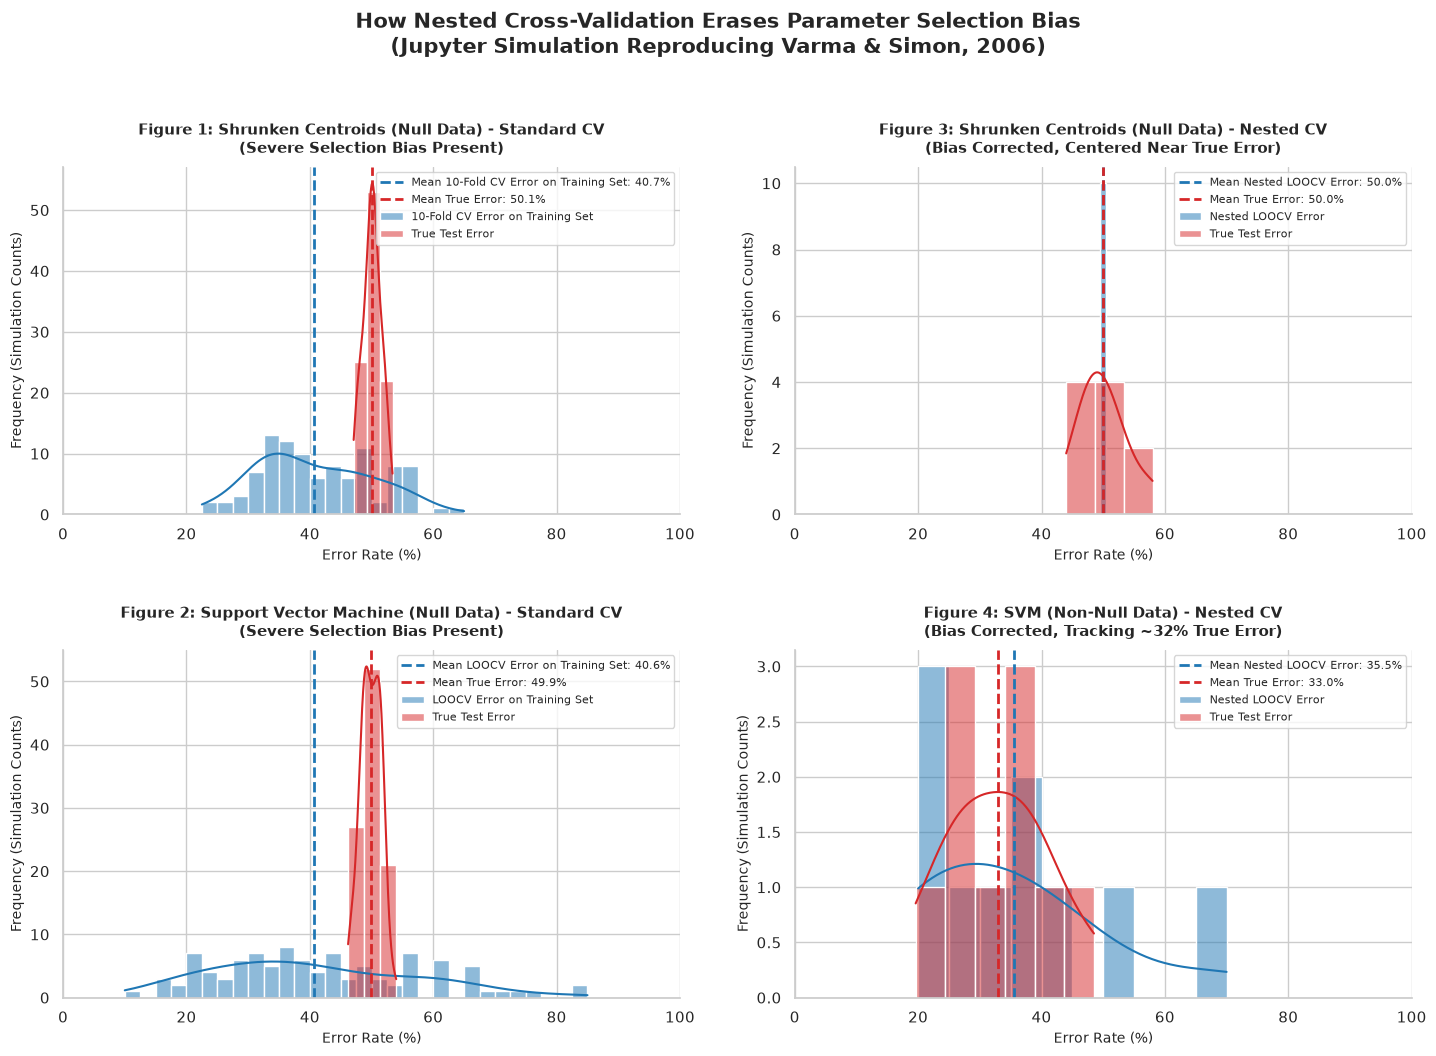

In [6]:
# =====================================================================
# CODE BLOCK 5: COMPARATIVE PLOTTING (REPLICATING FIGURES 1-4)
# =====================================================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set professional plotting aesthetics
sns.set_theme(style='whitegrid', palette='colorblind', font='DejaVu Sans')

# Define professional color mappings matching the original paper's style
cv_color = '#1f77b4'  # Deep Slate Blue for Cross-Validation Estimates
true_color = '#d62728' # Crimson Red for Independent True Test Errors

# ---------------------------------------------------------------------
# 1. DEFINE ADAPTIVE PLOTTING SUB-FUNCTIONS
# ---------------------------------------------------------------------
def plot_error_distributions(ax, cv_data, true_data, title, xlabel, cv_label, is_nested=False):
    """Plots overlapping histograms and KDEs with explicit mean annotations."""
    cv_pct = np.asarray(cv_data) * 100
    true_pct = np.asarray(true_data) * 100
    cv_mean = np.mean(cv_pct)
    true_mean = np.mean(true_pct)
    bin_width = 2.5 if len(cv_data) > 20 else 5.0

    # Constant simulation results need one explicit bin because automatic
    # bin-width calculation produces zero-width bins.
    for data, color, label in (
        (cv_pct, cv_color, cv_label),
        (true_pct, true_color, "True Test Error"),
    ):
        if np.ptp(data) == 0:
            sns.histplot(data, color=color, kde=False, label=label, ax=ax, alpha=0.5, bins=1)
        else:
            sns.histplot(data, color=color, kde=True, label=label, ax=ax, alpha=0.5, binwidth=bin_width)

    ax.axvline(cv_mean, color=cv_color, linestyle='--', linewidth=2, label=f"Mean {cv_label}: {cv_mean:.1f}%")
    ax.axvline(true_mean, color=true_color, linestyle='--', linewidth=2, label=f"Mean True Error: {true_mean:.1f}%")
    ax.set_title(title, fontsize=11, fontweight='bold', pad=10)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel("Frequency (Simulation Counts)", fontsize=10)
    ax.set_xlim(0, 100)
    ax.legend(fontsize=8, loc='upper left' if cv_mean > 50 else 'upper right')

    bias = cv_mean - true_mean
    print(f"  {title.split(':')} Analysis:")
    print(f"    Avg CV Error: {cv_mean:.1f}% | Avg True Test Error: {true_mean:.1f}% | Mean Bias: {bias:+.1f}%")

# ---------------------------------------------------------------------
# 2. EVALUATE WORKSPACE AND GENERATE ACTIVE SUBPLOTS
# ---------------------------------------------------------------------
print("--- CHECKING WORKSPACE VARIABLES AND GENERATING FIGURE ---")

sc_standard_ready = 'sc_cv_errors' in globals() and 'sc_true_errors' in globals()
sc_nested_ready   = 'sc_nested_errors' in globals() and 'sc_true_errors_nested' in globals()
svm_standard_ready = 'svm_cv_errors' in globals() and 'svm_true_errors' in globals()
svm_nested_ready   = 'svm_nested_errors' in globals() and 'svm_true_errors_nested' in globals()

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle("How Nested Cross-Validation Erases Parameter Selection Bias\n(Jupyter Simulation Reproducing Varma & Simon, 2006)",
             fontsize=15, fontweight='bold', y=0.98)

# Panel 1: Shrunken Centroids Standard CV (Null Data) - Replicates Figure 1
if sc_standard_ready:
    plot_error_distributions(
        axes[0, 0], sc_cv_errors, sc_true_errors,
        title="Figure 1: Shrunken Centroids (Null Data) - Standard CV\n(Severe Selection Bias Present)",
        xlabel="Error Rate (%)", cv_label="10-Fold CV Error on Training Set"
    )
else:
    axes[0, 0].text(0.5, 0.5, "Cell 2 Not Executed Yet\n(Run Shrunken Centroids Standard CV)", ha='center', va='center', fontsize=12, color='gray')
    print("  [Panel 1] Shrunken Centroids (Standard) data is missing.")

# Panel 2: Shrunken Centroids Nested CV (Null Data) - Replicates Figure 3
if sc_nested_ready:
    plot_error_distributions(
        axes[0, 1], sc_nested_errors, sc_true_errors_nested,
        title="Figure 3: Shrunken Centroids (Null Data) - Nested CV\n(Bias Corrected, Centered Near True Error)",
        xlabel="Error Rate (%)", cv_label="Nested LOOCV Error"
    )
else:
    axes[0, 1].text(0.5, 0.5, "Cell 4A Not Executed Yet\n(Run Shrunken Centroids Nested CV)", ha='center', va='center', fontsize=12, color='gray')
    print("  [Panel 2] Shrunken Centroids (Nested) data is missing.")

# Panel 3: SVM Standard CV (Null Data) - Replicates Figure 2
if svm_standard_ready:
    plot_error_distributions(
        axes[1, 0], svm_cv_errors, svm_true_errors,
        title="Figure 2: Support Vector Machine (Null Data) - Standard CV\n(Severe Selection Bias Present)",
        xlabel="Error Rate (%)", cv_label="LOOCV Error on Training Set"
    )
else:
    axes[1, 0].text(0.5, 0.5, "Cell 3 Not Executed Yet\n(Run SVM Standard CV)", ha='center', va='center', fontsize=12, color='gray')
    print("  [Panel 3] SVM (Standard) data is missing.")

# Panel 4: SVM Nested CV (Non-Null Data) - Replicates Figure 4
if svm_nested_ready:
    plot_error_distributions(
        axes[1, 1], svm_nested_errors, svm_true_errors_nested,
        title="Figure 4: SVM (Non-Null Data) - Nested CV\n(Bias Corrected, Tracking ~32% True Error)",
        xlabel="Error Rate (%)", cv_label="Nested LOOCV Error"
    )
else:
    axes[1, 1].text(0.5, 0.5, "Cell 4B Not Executed Yet\n(Run SVM Nested CV)", ha='center', va='center', fontsize=12, color='gray')
    print("  [Panel 4] SVM (Nested) data is missing.")

sns.despine(fig=fig)
plt.tight_layout(pad=2.5)
fig.savefig('comparative_error_distributions.png', dpi=150, bbox_inches='tight')
print("\nSuccess! Saved visual comparison to 'comparative_error_distributions.png'")
plt.show()